In [18]:
query = '연봉 5천만원인 직장인의 소득세는?'

In [19]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

embedding_function = OpenAIEmbeddings(model = 'text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='imcome_tex_collection',
    persist_directory='./chroma'
)

In [20]:
retriever = vector_store.as_retriever(
    search_kwargs={'k': 3}
)

In [21]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

graph_builder = StateGraph(AgentState)

In [22]:
def retrieve(state: AgentState):
    query = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

In [23]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')

In [24]:
from langsmith import Client

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")

In [25]:
def generate(state: AgentState):
    query = state['query']
    context = state['context']
    rag_chain = generate_prompt | llm
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

## 문서의 관련성을 측정

- [angchain-ai/rag-document-relevance](https://smith.langchain.com/hub/langchain-ai/rag-document-relevance) 프롬프트 활용

### System

```text
You are a teacher grading a quiz. 

You will be given a QUESTION and a set of FACTS provided by the student. 

Here is the grade criteria to follow:
(1) You goal is to identify FACTS that are completely unrelated to the QUESTION
(2) If the facts contain ANY keywords or semantic meaning related to the question, consider them relevant
(3) It is OK if the facts have SOME information that is unrelated to the question (2) is met 

Score:
A score of 1 means that the FACT contain ANY keywords or semantic meaning related to the QUESTION and are therefore relevant. This is the highest (best) score. 
A score of 0 means that the FACTS are completely unrelated to the QUESTION. This is the lowest possible score you can give.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct. 

Avoid simply stating the correct answer at the outset.
```

### User
```text
FACTS: {{documents}} 
QUESTION: {{question}}
```

In [26]:
doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance")

In [27]:
from typing import Literal

def check_doc_relevance(state: AgentState) -> Literal['generate', 'rewrite']:
    query = state['query']
    context = state['context']
    print(f'context == {context}')

    doc_relevance_rag_chain = doc_relevance_prompt | llm
    response = doc_relevance_rag_chain.invoke({'question': query, 'documents': context})
    print(f'doc relevance response == {response}')

    if response['Score'] == 1:
        return 'generate'
    return 'rewrite'

In [28]:
from langchain_core.prompts import PromptTemplate

dictionary = ['사람과 관련된 표현 -> 거주자', '직장인 -> 거주자']

rewrite_prompt = PromptTemplate.from_template(f"""
사용자의 질문을 보고, 우리의 사전을 참고해 사용자의 질문을 변경해주세요.
사전: {dictionary}
질문: {{query}}
""")

In [29]:
from langchain_core.output_parsers import StrOutputParser

def rewrite(state: AgentState):
    query = state['query']
    print(f'rewrite = {query}')
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    response = rewrite_chain.invoke({'query': query})
    return {'query': response}

In [30]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

In [31]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve', check_doc_relevance)
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)


In [32]:
graph = graph_builder.compile()

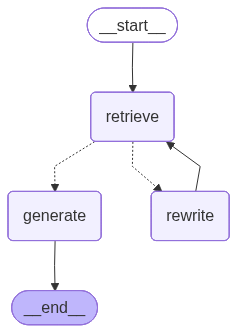

In [33]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = {'query': query}
graph.invoke(initial_state)

context == [Document(id='fbe91ac3-b02c-4310-b25f-9493c552c9aa', metadata={'source': './documents/income_tax.txt'}, page_content='2. 배당소득에 대해서는 다음에 규정하는 세율\n   가. 제17조제1항제3호에 따른 출자공동사업자의 배당소득에 대해서는 100분의 25\n   나. 그 밖의 배당소득에 대해서는 100분의 14\n3. 원천징수대상 사업소득에 대해서는 100분의 3. 다만, 외국인 직업운동가가 한국표준산업분류에 따른 스포츠 클럽 운영업 중 프로스포츠구단과의 계약에 따라 용역을 제공하고 받는 소득에 대해서는 100분의 20으로 한다. \n4. 근로소득에 대해서는 기본세율. 다만, 일용근로자의 근로소득에 대해서는 100분의 6으로 한다.\n5. 공적연금소득에 대해서는 기본세율\n   5의2.제20조의3제1항제1호나목 및 다음에 따른 연금계좌 납입액이나 운용실적에 따라 증가된 금액을 연금수령한 연금소득자에 대해서는 다음 각 목의 구분에 따른 세율. 이 경우 각 목의 요건을 동시에 충족하는 때에는 낮은 세율을 적용한다.\n   가. 연금소득자의 나이에 따른 다음의 세율\n| 나이(연금수령일 현재) | 세율     |\n   |------------------|--------|\n   | 70세 미만            | 100분의 5 |\n   | 70세 이상 80세 미만   | 100분의 4 |\n   | 80세 이상            | 100분의 3 |\n나. 삭제 <2014. 12. 23.>\n소득세법\n5의3. 제20조의3제1항제2호가목에 따라 퇴직소득을 연금수령하는 연금소득에 대해서는 다음 각 목의 구분에 따른 세율. 이 경우 연금 실제 수령연차 및 연금외수령 원천징수세율은 구체적인 내용은 대통령령으로 정한다.\n  가. 연금 실제 수령연차가 10년 이하인 경우: 연금외수령 원천징수세율의 100분의 70\n  나. 연금 실제 수령연차가 10년을